# Statistics for Data Analysis with Python

The aim is not to memorise code. The aim is to learn a reliable workflow:

1. define a question,
2. clean the data carefully,
3. describe distributions,
4. compare groups,
5. measure uncertainty,
6. test whether an observed difference is unusual under a null model,
7. communicate the result in plain language.

The same workflow transfers directly to your assessment, where the dataset changes but the statistical reasoning does not.


## What you should be able to do by the end

1.1 **Describe a variable properly** using counts, proportions, histograms, boxplots and summary statistics.  
1.2 **Compare two groups** using distributions, PMFs, ECDFs and effect size.  
1.3 **Model a continuous variable** with a simple theoretical distribution and understand what a density means.  
1.4 **Study a relationship** using a scatter plot, correlation and a simple regression line.  
1.5 **Estimate uncertainty** with a bootstrap confidence interval.  
1.6 **Test a claim** with a permutation test.  
1.7 **Write an interpretation** that is statistically sound and useful to a non-technical reader.


## Why these topics matter for the assessment

Keep this transfer idea in mind all the way through:

- **NSFG pregnancy length** becomes **crime counts, outcome counts, or monthly rates**.
- **First births vs later births** becomes **2024 vs 2025**, **borough A vs borough B**, or **West Midlands vs another force**.
- **Birth weight vs maternal age** becomes **crime rate vs deprivation**, **crime volume vs workforce**, or **crime type vs resolution pattern**.


## 0. Setup, Load dataset, Working Set and Validate
### 0.1 Setup


In [ ]:
# Do: import the small set of libraries used throughout the tutorial.
from pathlib import Path
import urllib.request
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RNG = np.random.default_rng(42)
PROJECT_ROOT = Path("nsfg_tutorial_project")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for p in [DATA_DIR, OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_ROOT.resolve())


Project folder: /content/nsfg_tutorial_project


### 0.2 Load the NSFG dataset

In [ ]:
# Do: download the raw NSFG pregnancy file and its dictionary, then load the fixed-width file with pandas.
from pathlib import Path
import urllib.request
import re
import pandas as pd

def download_if_needed(url: str, dest: Path, min_bytes: int = 1000) -> Path:
    dest.parent.mkdir(parents=True, exist_ok=True)

    need_download = True
    if dest.exists():
        try:
            if dest.stat().st_size >= min_bytes:
                need_download = False
            else:
                print(f"Existing file too small, re-downloading: {dest.name}")
        except Exception:
            pass

    if need_download:
        print(f"Downloading {dest.name} ...")
        urllib.request.urlretrieve(url, dest)
    else:
        print(f"Already present: {dest.name}")

    return dest

BASE = "https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/data"
dct_path = download_if_needed(f"{BASE}/2002FemPreg.dct", DATA_DIR / "2002FemPreg.dct")
dat_path = download_if_needed(f"{BASE}/2002FemPreg.dat.gz", DATA_DIR / "2002FemPreg.dat.gz")

# Correct regex patterns: single backslashes inside raw strings
_COLUMN_PAT = re.compile(r"_column\((\d+)\)")
_VAR_PAT = re.compile(r"^\s*(\S+)\s+(\S+)\s+(%[^\s]+)")
_FMT_PAT = re.compile(r"%(\d+)(?:\.\d+)?[A-Za-z]")

def parse_dct_to_colspecs(dct_file: Path, encoding: str = "utf-8"):
    colspecs, colnames = [], []

    with dct_file.open("r", encoding=encoding, errors="ignore") as f:
        lines = f.readlines()

    for line in lines:
        if "_column(" not in line:
            continue

        m_col = _COLUMN_PAT.search(line)
        if not m_col:
            continue
        start = int(m_col.group(1)) - 1

        rest = line[m_col.end():].strip()
        m_var = _VAR_PAT.match(rest)
        if not m_var:
            continue

        _, name, fmt = m_var.groups()
        m_fmt = _FMT_PAT.search(fmt)
        if not m_fmt:
            continue

        width = int(m_fmt.group(1))
        colspecs.append((start, start + width))
        colnames.append(name)

    if not colspecs:
        print("First 20 lines of dictionary file for debugging:")
        for i, line in enumerate(lines[:20], start=1):
            print(f"{i:02d}: {line.rstrip()}")
        raise ValueError("No columns were parsed from the .dct file.")

    return colspecs, colnames

colspecs, colnames = parse_dct_to_colspecs(dct_path)

print("Parsed columns:", len(colnames))
print("First 10 columns:", colnames[:10])

preg_raw = pd.read_fwf(
    dat_path,
    colspecs=colspecs,
    names=colnames,
    header=None,
    compression="gzip",
)

print("Loaded shape:", preg_raw.shape)
preg_raw.head()

Already present: 2002FemPreg.dct
Already present: 2002FemPreg.dat.gz
Parsed columns: 243
First 10 columns: ['caseid', 'pregordr', 'howpreg_n', 'howpreg_p', 'moscurrp', 'nowprgdk', 'pregend1', 'pregend2', 'nbrnaliv', 'multbrth']
Loaded shape: (13593, 243)


,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,poverty_i,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231


In [ ]:
preg_raw

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,poverty_i,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588,12571,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227
13589,12571,2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227
13590,12571,3,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227
13591,12571,4,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,4670.540953,5795.692880,6269.200989,1,78,1227


### 0.3 Build a clean working dataset

We keep the raw data unchanged and create analysis-ready columns. This is a good habit in any assessed project.


In [ ]:
# Do: keep only the variables we need, convert to numeric, and build clean analysis columns.
required_cols = ["caseid", "pregordr", "outcome", "birthord", "prglngth", "birthwgt_lb", "birthwgt_oz", "agepreg", "finalwgt"]

# Copy and Convert to numeric; unparseable values become NaN
preg = preg_raw.loc[:, required_cols].apply(pd.to_numeric, errors="coerce")


# Known coded values for missing or impossible birth weights in this dataset.
preg["birthwgt_lb"] = preg["birthwgt_lb"].replace([51, 97, 98, 99], np.nan)
preg["birthwgt_oz"] = preg["birthwgt_oz"].replace([97, 98, 99], np.nan)

# Build analysis-ready variables.
preg["agepreg_years"] = preg["agepreg"] / 100
preg["totalwgt_lb"] = preg["birthwgt_lb"] + preg["birthwgt_oz"] / 16
preg["is_live_birth"] = preg["outcome"].eq(1)
preg["is_first_baby"] = preg["birthord"].eq(1)

# Conservative plausibility rules for teaching purposes.
preg["prglngth_clean"] = preg["prglngth"].where(preg["prglngth"].between(20, 50))
preg["totalwgt_lb_clean"] = preg["totalwgt_lb"].where(preg["totalwgt_lb"].between(0.5, 20))
preg["agepreg_years_clean"] = preg["agepreg_years"].where(preg["agepreg_years"].between(10, 60))

live = preg.query("is_live_birth").copy()
firsts = live.query("is_first_baby").copy()
others = live.query("~is_first_baby").copy()

pd.DataFrame({"subset": ["all pregnancies", "live births", "first babies", "other babies"],
              "rows": [len(preg), len(live), len(firsts), len(others)]
})



,subset,rows
0,all pregnancies,13593
1,live births,9148
2,first babies,4413
3,other babies,4735


In [ ]:
preg

,caseid,pregordr,outcome,birthord,prglngth,birthwgt_lb,birthwgt_oz,agepreg,finalwgt,agepreg_years,totalwgt_lb,is_live_birth,is_first_baby,prglngth_clean,totalwgt_lb_clean,agepreg_years_clean
0,1,1,1,1.0,39,8.0,13.0,3316.0,6448.271112,33.16,8.8125,True,True,39.0,8.8125,33.16
1,1,2,1,2.0,39,7.0,14.0,3925.0,6448.271112,39.25,7.8750,True,False,39.0,7.8750,39.25
2,2,1,1,1.0,39,9.0,2.0,1433.0,12999.542264,14.33,9.1250,True,True,39.0,9.1250,14.33
3,2,2,1,2.0,39,7.0,0.0,1783.0,12999.542264,17.83,7.0000,True,False,39.0,7.0000,17.83
4,2,3,1,3.0,39,6.0,3.0,1833.0,12999.542264,18.33,6.1875,True,False,39.0,6.1875,18.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588,12571,1,1,1.0,39,6.0,3.0,1791.0,6269.200989,17.91,6.1875,True,True,39.0,6.1875,17.91
13589,12571,2,2,NaN,6,NaN,NaN,1850.0,6269.200989,18.50,NaN,False,False,NaN,NaN,18.50
13590,12571,3,2,NaN,5,NaN,NaN,1975.0,6269.200989,19.75,NaN,False,False,NaN,NaN,19.75
13591,12571,4,1,2.0,39,7.0,8.0,2158.0,6269.200989,21.58,7.5000,True,False,39.0,7.5000,21.58


### 0.4 Validate before you analyse

Before analysis, ensure that the data loaded correctly and the subsets you need actually exist.


In [ ]:
# Do: perform quick validation checks before analysis.
validation = pd.DataFrame({
    "check": [
        "Rows loaded",
        "Unique respondents",
        "Live births present",
        "First births present",
        "Other births present",
        # "Pregnancy length missing (live births)",
        # "Birth weight missing (live births)"
    ],
    "value": [
        len(preg),
        preg["caseid"].nunique(),
        int(live.shape[0] > 0),
        int(firsts.shape[0] > 0),
        int(others.shape[0] > 0),
        # int(live["prglngth_clean"].isna().sum()),
        # int(live["totalwgt_lb_clean"].isna().sum())
    ]
})
validation


,check,value
0,Rows loaded,13593
1,Unique respondents,5033
2,Live births present,1
3,First births present,1
4,Other births present,1


## 1. Describe distributions first

> ## Do first pregancies arrive late?
- We need to compare pregnancy length for first births and later births.
- The first question is usually not '_Is there a significant difference?_'  
  - Instead, **what do these variables look like?**

### 1.1 Summary Statistics
For numeric variables, `pandas.Series.describe()` generates descriptive statistics that summarise:
- Central tendency (where the data are concentrated)
- Dispersion (how variable they are)
- Aspects of the distribution



In [ ]:
preg['prglngth'].describe()

,prglngth
count,13593.000000
mean,29.531229
std,13.802523
min,0.000000
25%,13.000000
50%,39.000000
75%,39.000000
max,50.000000


In [ ]:
firsts['prglngth'].describe()

,prglngth
count,4413.000000
mean,38.600952
std,2.791901
min,0.000000
25%,39.000000
50%,39.000000
75%,40.000000
max,48.000000


In [ ]:
others['prglngth'].describe()

,prglngth
count,4735.000000
mean,38.522914
std,2.615852
min,4.000000
25%,39.000000
50%,39.000000
75%,39.000000
max,50.000000


In [ ]:
# Do: compare the main descriptive statistics for first and later births.
summary_prglngth_raw = (
    pd.DataFrame({
        "first births": firsts["prglngth"],
        "other births": others["prglngth"]
    }).describe().T
)
summary_prglngth_raw


,count,mean,std,min,25%,50%,75%,max
first births,4413.0,38.600952,2.791901,0.0,39.0,39.0,40.0,48.0
other births,4735.0,38.522914,2.615852,4.0,39.0,39.0,39.0,50.0


## 1.1 Core questions to ask in any data analysis task

These are the questions I want you to ask whenever you analyse a dataset.

### 1. Check data quality first

Before interpreting any result, ask:

- Are there **invalid values**, **coding errors**, or **impossible values**?
- Are there **missing values** that need to be handled explicitly?
- Are there **extreme observations** that may be genuine outliers or data-entry problems?
- Are the variables stored in the **right type and units**?

This step comes first because a statistical result is only as trustworthy as the data and decisions behind it.

---

### 2. Identify the observed effect in the sample

An **observed effect** is a pattern or difference measured in the sample. Common examples include:

- **Difference between two groups** (e.g., difference in means, medians, or proportions)  
- **Association between two quantitative variables** (e.g., a correlation between age and birth weight)  
- **Difference between observed and expected counts** (e.g., counts across categories that do not match what we would expect)  

In this example, the observed effect is the **difference in mean pregnancy length** between first pregnancies and later pregnancies.

> Because this is a **sample estimate**, two further questions should follow.

---
### 3. How big is the effect?

This is a question about **magnitude** or **practical importance**. Is the effect large enough to matter in practice?

Useful methods to assess this magnitude or pratical significance, include:
- **Raw effect size**  
  - Such as a difference in means, medians, proportions, or a relative change  
  - *e.g.,: 0.078 weeks, about 0.55 days, or about 0.2%*
- **Standardised effect size**
  - Judge magnitude relative to variability
  - e.g., **Cohen's d** for a difference in means
- **Comparison with a meaningful domain threshold**  
  - Judge whether the effect is large enough to matter in practice
  - e.g., a difference of 0.55 days may be statistically detectable, but may be too small to matter in practice
- **Visual comparison of distributions**  
  - such as side-by-side boxplots, ECDFs, or density plots

---

### 4. How strong is the evidence that the effect is not just sampling variation?

This is a question about **sampling uncertainty** and **evidence against a null hypothesis**.

#### 4.1 Estimate uncertainty

Use an interval estimate to show a plausible range for the population effect:

- **confidence interval for a difference in means**
- **confidence interval for a difference in proportions**
- **bootstrap confidence interval** when a resampling approach is preferred

#### 4.2 Test against a null model - Hypothesis Testing

**Hypothesis tests**: address whether the observed effect is unusual under the null model. Choose the method to match the type of variables:

- **Numeric outcome, two groups**  
  - Welch two-sample *t*-test, or a permutation test
- **Numeric outcome, more than two groups**  
  - ANOVA  
- **Categorical outcome or counts**  
  - chi-square test, two-proportion *z*-test, or Fisher's exact test
- **Association between two quantitative variables**  
  - Pearson correlation test, Spearman rank correlation test, or a test for a linear regression coefficient

The key point is that these methods help us judge whether the observed effect is **larger than we would expect from random sampling variation alone**.

---

### 5. The transferable skill

In any new dataset, keep the same sequence in mind:

1. **check data quality**
2. **identify the observed effect**
3. **measure how large it is**
4. **measure how uncertain it is**
5. **choose a method that matches the variable type and the question**



          

     
            
          


In [ ]:
smallest_preglen = firsts['prglngth'].sort_values()
largest_preglen = others['prglngth'].sort_values(ascending=False)
display(smallest_preglen)
display(largest_preglen)


,prglngth
6458,0
8919,17
1041,20
7800,21
13173,22
...,...
12028,46
11357,47
6889,48
7158,48


,prglngth
4783,50
8998,50
4920,48
7161,48
7592,48
...,...
541,18
10492,17
11887,13
138,9


In [ ]:
# Do: compare the main descriptive statistics for first and later births.
summary_prglngth = (
    pd.DataFrame({
        "first births": firsts["prglngth_clean"],
        "other births": others["prglngth_clean"]
    }).describe().T
)
summary_prglngth


,count,mean,std,min,25%,50%,75%,max
first births,4411.0,38.614600,2.711896,20.0,39.0,39.0,40.0,48.0
other births,4729.0,38.554874,2.451217,21.0,39.0,39.0,39.0,50.0


## Effect size (Cohen’s d)
- Statistical work should report both **how big** a difference is and **how uncertain** it is.
- The groups (first and others) have different sample sizes, so proportions are better than raw counts for comparing shape
- **Main Idea**: the mean difference alone can be misleading; Cohen’s d scales the mean difference by the typical spread.


In [ ]:
# Do: quantify practical importance, not only statistical evidence.
def cohens_d(x, y):
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    y = pd.Series(y).dropna().to_numpy(dtype=float)
    n1, n2 = len(x), len(y)
    s1, s2 = x.std(ddof=1), y.std(ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return (x.mean() - y.mean()) / sp

d = cohens_d(firsts["prglngth_clean"], others["prglngth_clean"])
pd.DataFrame({"effect_size": ["Cohen's d"], "value": [d]})


,effect_size,value
0,Cohen's d,0.023147


## How big is the effect? Visual comparison of distributions
Summary statistics are useful, but they do not show the full shape. For comparing two numeric groups, we will use:

- a **histogram** to see the overall distribution
- an **ECDF** to compare cumulative distributions directly

#### Frequency tables of pregnancy length
A **Frequency Table** - values of a variable and their frequencies

- `value_counts()` gives the frequency of each unique value.
- Then, use `sort_index()` so the weeks appear in numerical order.

In [ ]:
# Do: build a frequency table for pregnancy length in weeks.
ftab_first = firsts["prglngth_clean"].value_counts().sort_index().rename("firsts")
ftab_other = others["prglngth_clean"].value_counts().sort_index().rename("others")

freq_table = pd.concat([ftab_first, ftab_other], axis=1).fillna(0).astype(int)
freq_table



,firsts,others
prglngth_clean,,
20.0,1,0
21.0,1,1
22.0,3,4
23.0,1,0
24.0,7,6
25.0,1,2
26.0,16,19
27.0,1,2
28.0,24,8


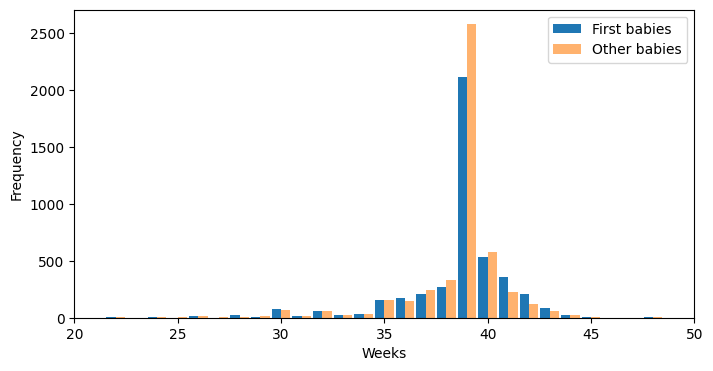

In [ ]:
x = freq_table.index.to_numpy()
width = 0.45

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, freq_table["firsts"], width=width, label="First babies")
plt.bar(x + width/2, freq_table["others"], width=width, alpha=0.6, label="Other babies")

plt.xlabel("Weeks")
plt.ylabel("Frequency")
plt.xlim(20, 50)
plt.legend();

### Better comparison: relative frequencies

- Because the two groups have different sample sizes, relative frequencies (**probabilities for exact values**) are usually better than raw counts for comparing shape. PMF for a discrete variable

- A relative frequency is just:

`count at a value` divided by `total count in the group`

In [ ]:
# Do: convert counts into proportions to make a PMF for this discrete variable.
prop_first = firsts["prglngth"].value_counts(normalize=True).sort_index().rename("firsts")
prop_other = others["prglngth"].value_counts(normalize=True).sort_index().rename("others")

prop_table = pd.concat([prop_first, prop_other], axis=1).fillna(0)
prop_table.head(10)

,firsts,others
prglngth,,
0,0.000227,0.000000
17,0.000227,0.000211
20,0.000227,0.000000
21,0.000227,0.000211
22,0.000680,0.000845
23,0.000227,0.000000
24,0.001586,0.001267
25,0.000227,0.000422
26,0.003626,0.004013


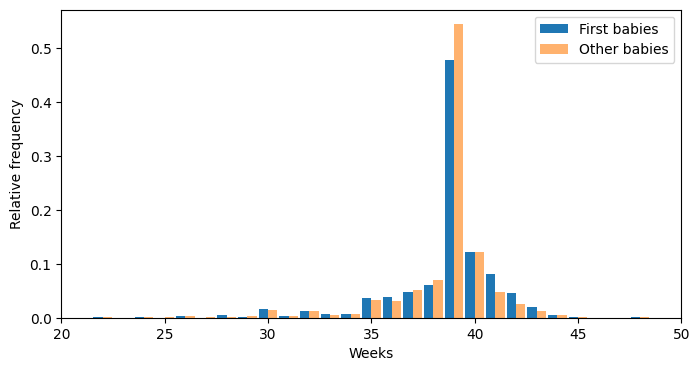

In [ ]:
x = prop_table.index.to_numpy()
width = 0.45

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, prop_table["firsts"], width=width, label="First babies")
plt.bar(x + width/2, prop_table["others"], width=width, alpha=0.6, label="Other babies")

plt.xlabel("Weeks")
plt.ylabel("Relative frequency")
plt.xlim(20, 50)
plt.legend();

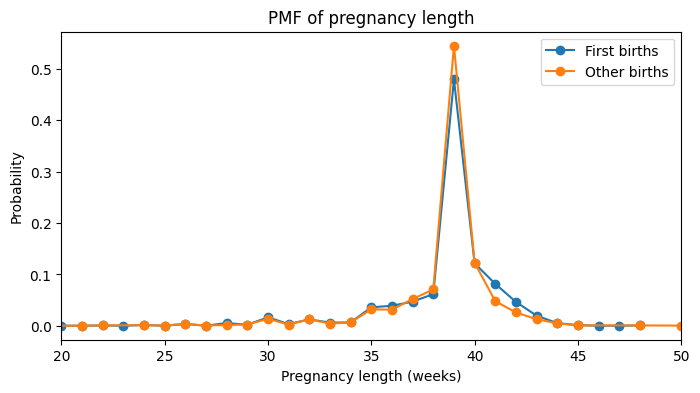

In [ ]:
# Do: plot the PMF - Probability Mass Function

plt.figure(figsize=(8, 4))
plt.plot(prop_first.index, prop_first, marker="o", label="First births")
plt.plot(prop_other.index, prop_other, marker="o", label="Other births")
plt.xlim(20, 50)
plt.xlabel("Pregnancy length (weeks)")
plt.ylabel("Probability")
plt.title("PMF of pregnancy length")
plt.legend()



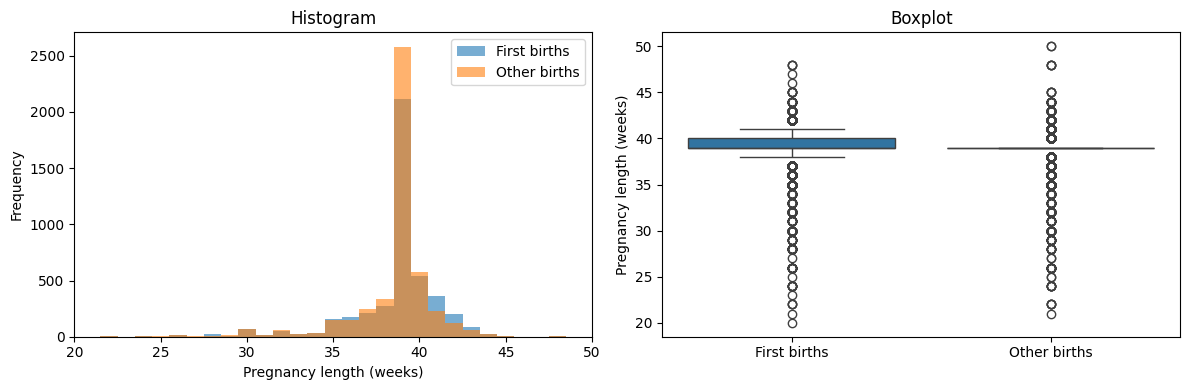

In [ ]:
# Do: look at shape, centre, spread and possible outliers.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.arange(19.5, 50.5, 1)
axes[0].hist(firsts["prglngth_clean"].dropna(), bins=bins, alpha=0.6, label="First births")
axes[0].hist(others["prglngth_clean"].dropna(), bins=bins, alpha=0.6, label="Other births")
axes[0].set(xlabel="Pregnancy length (weeks)", ylabel="Frequency", xlim=(20, 50), title="Histogram")
axes[0].legend()

sns.boxplot(
    data=pd.DataFrame({
        "group": ["First births"] * len(firsts) + ["Other births"] * len(others),
        "weeks": pd.concat([firsts["prglngth_clean"], others["prglngth_clean"]], ignore_index=True)
    }),
    x="group", y="weeks", ax=axes[1]
)
axes[1].set(xlabel="", ylabel="Pregnancy length (weeks)", title="Boxplot")

plt.tight_layout()



### Take-home message

A histogram and a boxplot together usually give a better first impression than either one alone. In coursework, do not just say *'the distribution looks normal'*. Say what you can actually see.


### ECDF for cumulative comparison

An ECDF is often the clearest comparison tool because it shows the proportion of observations at or below each value.


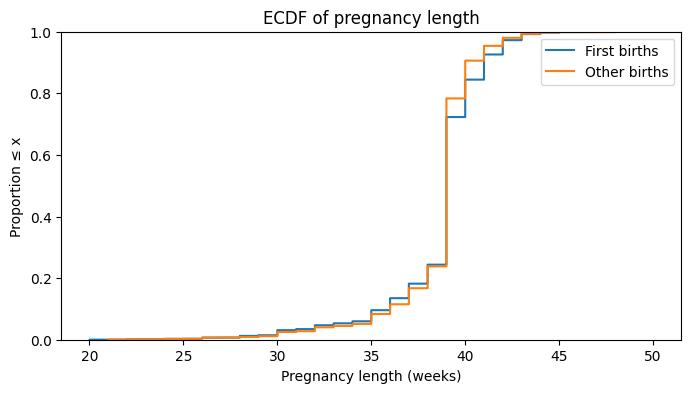

,group,P(length ≤ 39 weeks),Median length
0,First births,0.722638,39.0
1,Other births,0.782471,39.0


In [ ]:
# Do: show the cumulative view with an ECDF.
plt.figure(figsize=(8, 4))
sns.ecdfplot(data=firsts, x="prglngth_clean", label="First births")
sns.ecdfplot(data=others, x="prglngth_clean", label="Other births")
# plt.xlim(20, 50)
plt.xlabel("Pregnancy length (weeks)")
plt.ylabel("Proportion ≤ x")
plt.title("ECDF of pregnancy length")
plt.legend()
plt.show()

pd.DataFrame({
    "group": ["First births", "Other births"],
    "P(length ≤ 39 weeks)": [
        (firsts["prglngth_clean"] <= 39).mean(),
        (others["prglngth_clean"] <= 39).mean(),
    ],
    "Median length": [
        firsts["prglngth_clean"].median(),
        others["prglngth_clean"].median(),
    ]
})


### Interpretation

Use the ECDF when you want statements such as:
- 'about x% of cases are at or below this value',
- 'one group tends to be slightly larger than the other',
- 'the difference is concentrated in one part of the distribution'.


## Modelling a distribution

A model is useful when it gives a compact description of the data and helps answer probability questions. Birth weight is often approximately bell-shaped, so a normal model is a sensible starting point.


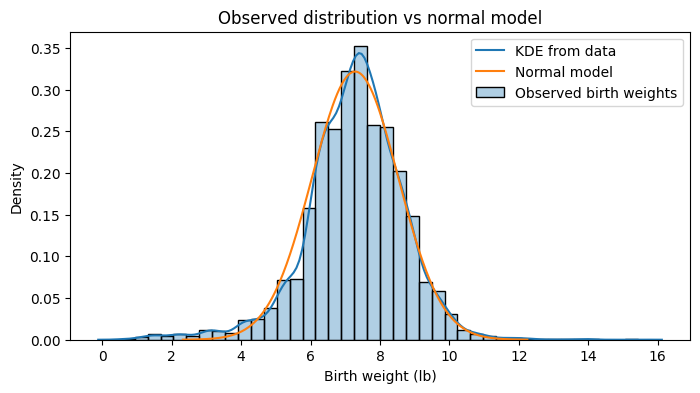

,trimmed_mean_lb,trimmed_sd_lb
0,7.282411,1.240571


In [ ]:
# Do: compare the birth-weight data to a simple normal model.
weights = live["totalwgt_lb_clean"].dropna()
trimmed = stats.trimboth(np.sort(weights.to_numpy()), 0.01)
mu = trimmed.mean()
sigma = trimmed.std(ddof=1)

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)

plt.figure(figsize=(8, 4))
sns.histplot(weights, bins=40, stat="density", alpha=0.35, label="Observed birth weights")
sns.kdeplot(weights, label="KDE from data")
plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sigma), label="Normal model")
plt.xlabel("Birth weight (lb)")
plt.ylabel("Density")
plt.title("Observed distribution vs normal model")
plt.legend()

pd.DataFrame({"trimmed_mean_lb": [mu], "trimmed_sd_lb": [sigma]})


## Probability density in practice

For continuous data, we work with **density**, not probability at a single exact value. The probability of a continuous variable being exactly one value is effectively zero; probability lives over **intervals**.


In [ ]:
# Do: answer interval questions with a continuous model.
p_under_6 = stats.norm.cdf(6, loc=mu, scale=sigma)
p_between_6_and_8 = stats.norm.cdf(8, loc=mu, scale=sigma) - stats.norm.cdf(6, loc=mu, scale=sigma)

pd.DataFrame({
    "question": [
        "P(weight < 6 lb) under normal model",
        "P(6 lb ≤ weight ≤ 8 lb) under normal model"
    ],
    "value": [p_under_6, p_between_6_and_8]
})


,question,value
0,P(weight < 6 lb) under normal model,0.150632
1,P(6 lb ≤ weight ≤ 8 lb) under normal model,0.567883


## Relationships between variables

We now move from one variable at a time to two variables together.


In [ ]:
# Do: study a simple relationship: maternal age and birth weight.
rel = live.loc[:, ["agepreg_years_clean", "totalwgt_lb_clean"]].dropna()

pearson_r, pearson_p = stats.pearsonr(rel["agepreg_years_clean"], rel["totalwgt_lb_clean"])
spearman_r, spearman_p = stats.spearmanr(rel["agepreg_years_clean"], rel["totalwgt_lb_clean"])
lin = stats.linregress(rel["agepreg_years_clean"], rel["totalwgt_lb_clean"])

plt.figure(figsize=(8, 4))
sns.regplot(
    data=rel,
    x="agepreg_years_clean",
    y="totalwgt_lb_clean",
    scatter_kws={"alpha": 0.15},
    line_kws={"linewidth": 2}
)
plt.xlabel("Age at end of pregnancy (years)")
plt.ylabel("Birth weight (lb)")
plt.title("Relationship: age and birth weight")
plt.show()

pd.DataFrame({
    "measure": ["Pearson r", "Spearman rho", "Slope (lb per year)", "R squared"],
    "value": [pearson_r, spearman_r, lin.slope, lin.rvalue**2],
    "p_value": [pearson_p, spearman_p, lin.pvalue, np.nan]
})


### Interpretation discipline

- **Correlation** measures association, not causation.
- A very small p-value does **not** mean the relationship is important.
- Always look at the plot before trusting a single summary number.


In [ ]:
# Do: estimate uncertainty with a bootstrap confidence interval for the mean difference.
a = firsts["prglngth_clean"].dropna().to_numpy(dtype=float)
b = others["prglngth_clean"].dropna().to_numpy(dtype=float)

def mean_diff(x, y):
    return np.mean(x) - np.mean(y)

boot = stats.bootstrap(
    data=(a, b),
    statistic=mean_diff,
    paired=False,
    vectorized=False,
    confidence_level=0.95,
    n_resamples=5000,
    random_state=42,
    method="percentile",
)

pd.DataFrame({
    "estimate_weeks": [mean_diff(a, b)],
    "ci_95_low": [boot.confidence_interval.low],
    "ci_95_high": [boot.confidence_interval.high]
})


,estimate_weeks,ci_95_low,ci_95_high
0,0.059726,-0.046616,0.165056


### Interpretation

A confidence interval gives a plausible range for the population quantity, given the data and method. If the interval is narrow and near zero, the practical difference is small.


## Hypothesis testing

A permutation test asks: if there were really no difference between the groups, how unusual would our observed difference be?
- Hypothesis (there's a difference) vs Null Hypothesis (there is no difference)

In [ ]:
# Do: run a permutation test for the null hypothesis of no difference in mean pregnancy length.
perm = stats.permutation_test(
    data=(a, b),
    statistic=mean_diff,
    permutation_type="independent",
    alternative="two-sided",
    n_resamples=5000,
    random_state=42,
)

pd.DataFrame({
    "observed_mean_difference_weeks": [mean_diff(a, b)],
    "p_value": [perm.pvalue]
})


,observed_mean_difference_weeks,p_value
0,0.059726,0.287942


### Interpretation

A p-value is **not** the probability that the null hypothesis is true. It is the probability of seeing data at least this extreme **if** the null model were true.


## Comparing proportions

This is a particularly transferable technique. Many real questions are about proportions rather than means.


In [ ]:
# Do: compare proportions using a clinically meaningful threshold.
preterm_first = firsts["prglngth_clean"].lt(37).dropna().astype(float).to_numpy()
preterm_other = others["prglngth_clean"].lt(37).dropna().astype(float).to_numpy()

def prop_diff(x, y):
    return np.mean(x) - np.mean(y)

boot_prop = stats.bootstrap(
    data=(preterm_first, preterm_other),
    statistic=prop_diff,
    paired=False,
    vectorized=False,
    confidence_level=0.95,
    n_resamples=5000,
    random_state=42,
    method="percentile",
)

pd.DataFrame({
    "group": ["First births", "Other births"],
    "Preterm proportion": [preterm_first.mean(), preterm_other.mean()]
}), pd.DataFrame({
    "difference_first_minus_other": [prop_diff(preterm_first, preterm_other)],
    "ci_95_low": [boot_prop.confidence_interval.low],
    "ci_95_high": [boot_prop.confidence_interval.high]
})


(          group  Preterm proportion
 0  First births            0.134829
 1  Other births            0.114889,
    difference_first_minus_other  ci_95_low  ci_95_high
 0                       0.01994   0.006533    0.033619)

# How this transfers directly to the police assessment

Use a similar logic on the police data:

- **Describe distributions**  
Start with monthly crime counts, crime rates, or outcome proportions. Use summary statistics, histograms, and boxplots.

- **Idetify the observed effect and it's size**  
  - Raw effect size, Standardised effect size, Comparison with a meaningful domain threshold, Visual comparison of distributions

- **Visual comparison of distributions**
  - When should you use a histogram, a boxplot, a PMF, or an ECDF? For example,
    - **Use PMFs for discrete categories** (e.g., distribution of crimes by type or outcomes by crime type).
    - **Use ECDFs for cumulative comparison** (e.g., compare monthly totals in 2024 and 2025, or compare two boroughs).

- **Use correlation for context** (e.g., deprivation vs crime rate, or workforce vs recorded crime volume).

- **Estimate uncertainty and Hypothesis Testing**
  - **Use bootstrap confidence intervals** (e.g., uncertainty for the difference in burglary rate between years). What is the difference between a point estimate and a confidence interval?
  - **Use permutation tests** (e.g., test whether the observed difference between two years or two areas is larger than expected by random variation alone). What does a `p-value` mean?

- **Write the conclusion properly**: State the direction, size, uncertainty, and practical meaning of the result.
